# AI-Powered Energy Consumption Forecasting
## Notebook 1: Exploratory Data Analysis (EDA)

**Dataset:** Hourly electricity consumption (MWh) — ~6 years (2016–2021)  
**Goal:** Understand patterns, seasonality, trends, and anomalies before modelling.

## 0. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

DATA_PATH = '../data/energy_consumption.csv'

## 1. Load & Parse Data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['Start time UTC', 'End time UTC'])
df.columns = ['start_utc', 'end_utc', 'consumption_mwh']

# Use start time as the index
df = df.set_index('start_utc').sort_index()
df = df[['consumption_mwh']]

print(f'Shape        : {df.shape}')
print(f'Date range   : {df.index.min()} → {df.index.max()}')
print(f'Total hours  : {len(df):,}')
print(f'Expected hrs : {int((df.index.max() - df.index.min()).total_seconds() / 3600) + 1:,}')
df.head(10)

Shape        : (52966, 1)
Date range   : 2015-12-31 21:00:00 → 2021-12-31 20:00:00
Total hours  : 52,966
Expected hrs : 52,608


,consumption_mwh
start_utc,
2015-12-31 21:00:00,10800
2015-12-31 22:00:00,10431
2015-12-31 23:00:00,10005
2016-01-01 00:00:00,9722
2016-01-01 01:00:00,9599
2016-01-01 02:00:00,9524
2016-01-01 03:00:00,9601
2016-01-01 04:00:00,9793
2016-01-01 05:00:00,9815


## 2. Basic Statistics

In [3]:
desc = df['consumption_mwh'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print(desc)
print(f'\nSkewness : {df.consumption_mwh.skew():.4f}')
print(f'Kurtosis : {df.consumption_mwh.kurt():.4f}')

count    52966.000000
mean      9488.750519
std       1576.241673
min       5341.000000
1%        6620.000000
5%        7142.000000
25%       8322.000000
50%       9277.000000
75%      10602.000000
95%      12270.000000
99%      13413.350000
max      15105.000000
Name: consumption_mwh, dtype: float64

Skewness : 0.4014
Kurtosis : -0.3345


## 3. Missing Values & Continuity Check

In [4]:
# Check explicit NaNs
print('Null values:', df.isnull().sum().values[0])

# Check for gaps (missing hourly timestamps)
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
missing_ts = full_range.difference(df.index)
print(f'Missing timestamps: {len(missing_ts)}')
if len(missing_ts) > 0:
    print('First few missing:', missing_ts[:10].tolist())

# Check duplicate timestamps
dupes = df.index.duplicated().sum()
print(f'Duplicate timestamps: {dupes}')

Null values: 0
Missing timestamps: 378
First few missing: [Timestamp('2016-01-11 12:00:00'), Timestamp('2016-01-11 13:00:00'), Timestamp('2016-01-11 14:00:00'), Timestamp('2016-01-11 15:00:00'), Timestamp('2016-01-11 16:00:00'), Timestamp('2016-01-11 17:00:00'), Timestamp('2016-01-29 10:00:00'), Timestamp('2016-04-04 16:00:00'), Timestamp('2016-04-04 17:00:00'), Timestamp('2016-04-04 18:00:00')]
Duplicate timestamps: 0


## 4. Full Time Series Overview

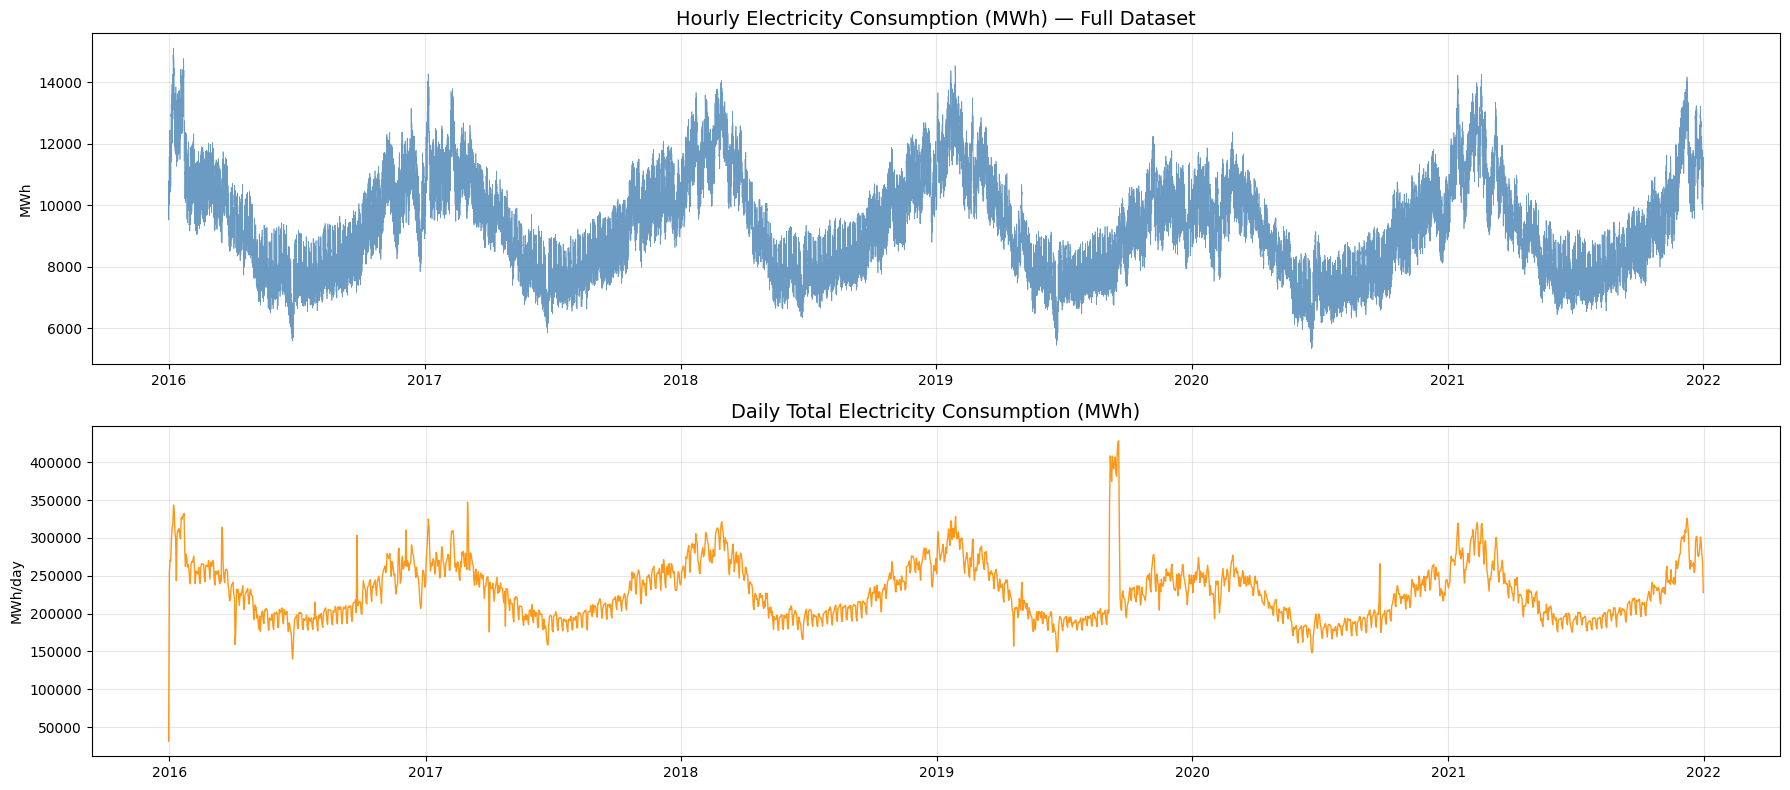

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))

# Raw hourly
axes[0].plot(df.index, df['consumption_mwh'], lw=0.5, color='steelblue', alpha=0.8)
axes[0].set_title('Hourly Electricity Consumption (MWh) — Full Dataset', fontsize=14)
axes[0].set_ylabel('MWh')

# Daily resampled for cleaner view
daily = df['consumption_mwh'].resample('D').sum()
axes[1].plot(daily.index, daily.values, lw=1, color='darkorange', alpha=0.9)
axes[1].set_title('Daily Total Electricity Consumption (MWh)', fontsize=14)
axes[1].set_ylabel('MWh/day')

plt.tight_layout()
plt.savefig('../outputs/figures/01_full_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Engineering (Time-Based)

In [6]:
df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek          # 0=Mon, 6=Sun
df['day_of_year'] = df.index.dayofyear
df['week']        = df.index.isocalendar().week.astype(int)
df['month']       = df.index.month
df['year']        = df.index.year
df['quarter']     = df.index.quarter
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

# Season mapping
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
df['season'] = df['month'].map(season_map)

print('Features added:')
print(df.dtypes)
df.head()

Features added:
consumption_mwh     int64
hour                int32
day_of_week         int32
day_of_year         int32
week                int64
month               int32
year                int32
quarter             int32
is_weekend          int64
season             object
dtype: object


,consumption_mwh,hour,day_of_week,day_of_year,week,month,year,quarter,is_weekend,season
start_utc,,,,,,,,,,
2015-12-31 21:00:00,10800,21,3,365,53,12,2015,4,0,Winter
2015-12-31 22:00:00,10431,22,3,365,53,12,2015,4,0,Winter
2015-12-31 23:00:00,10005,23,3,365,53,12,2015,4,0,Winter
2016-01-01 00:00:00,9722,0,4,1,53,1,2016,1,0,Winter
2016-01-01 01:00:00,9599,1,4,1,53,1,2016,1,0,Winter


## 6. Hourly Pattern (Daily Seasonality)

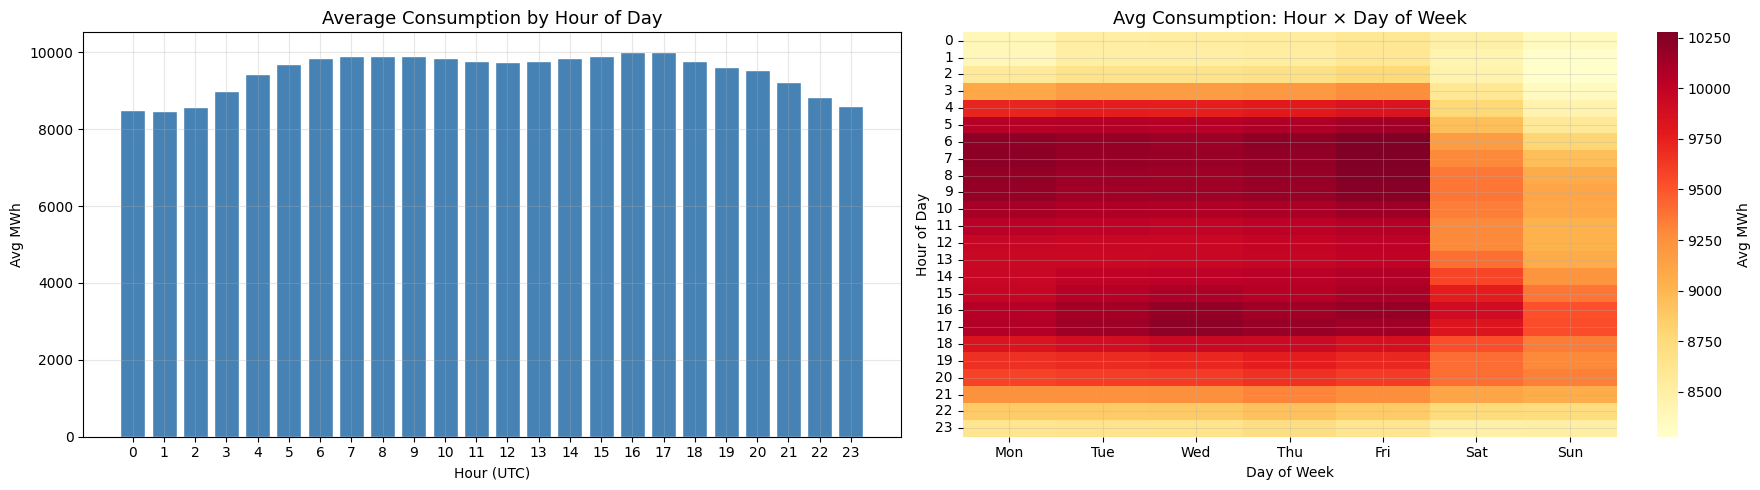

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Average by hour
hourly_avg = df.groupby('hour')['consumption_mwh'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='steelblue', edgecolor='white')
axes[0].set_title('Average Consumption by Hour of Day', fontsize=13)
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Avg MWh')
axes[0].set_xticks(range(0, 24))

# Hour x Weekday heatmap
pivot_hw = df.groupby(['hour', 'day_of_week'])['consumption_mwh'].mean().unstack()
pivot_hw.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(pivot_hw, ax=axes[1], cmap='YlOrRd', cbar_kws={'label': 'Avg MWh'})
axes[1].set_title('Avg Consumption: Hour × Day of Week', fontsize=13)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.savefig('../outputs/figures/02_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Weekly Pattern

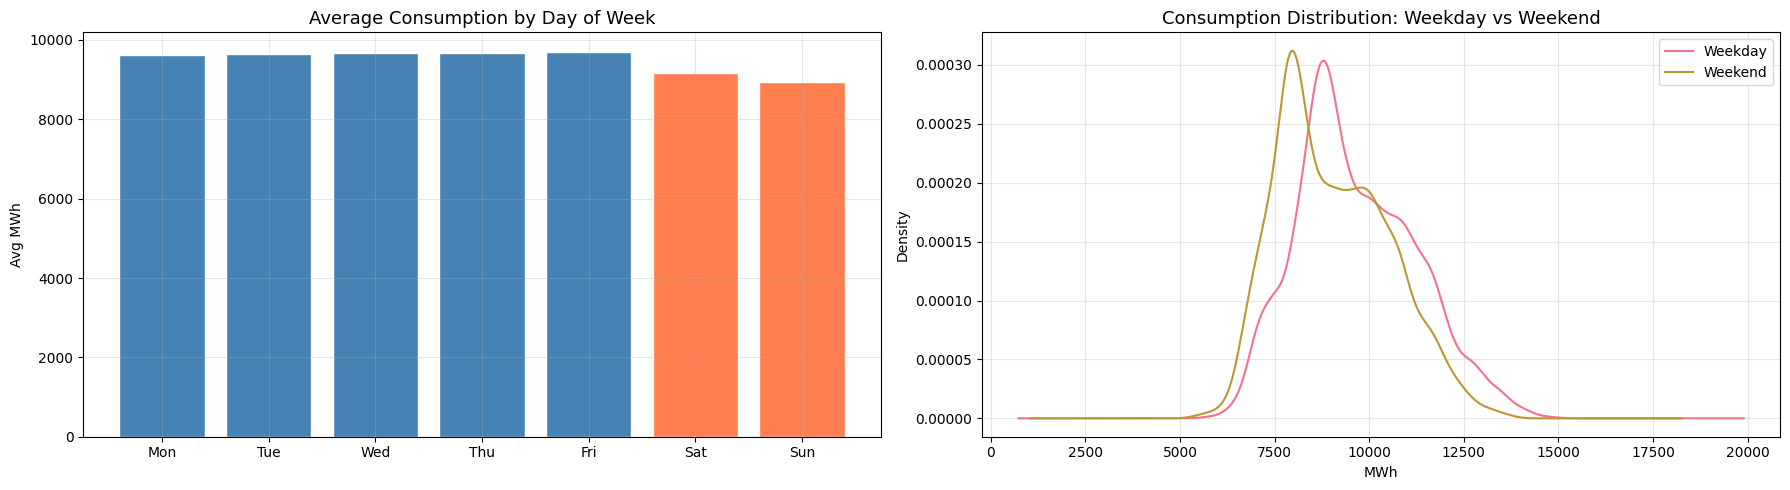

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

dow_avg = df.groupby('day_of_week')['consumption_mwh'].mean()
dow_avg.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[0].bar(dow_avg.index, dow_avg.values, color=['steelblue']*5 + ['coral']*2, edgecolor='white')
axes[0].set_title('Average Consumption by Day of Week', fontsize=13)
axes[0].set_ylabel('Avg MWh')

# Weekend vs Weekday distribution
df.groupby('is_weekend')['consumption_mwh'].plot(kind='density', ax=axes[1], legend=True)
axes[1].legend(['Weekday', 'Weekend'])
axes[1].set_title('Consumption Distribution: Weekday vs Weekend', fontsize=13)
axes[1].set_xlabel('MWh')

plt.tight_layout()
plt.savefig('../outputs/figures/03_weekly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Monthly & Seasonal Pattern

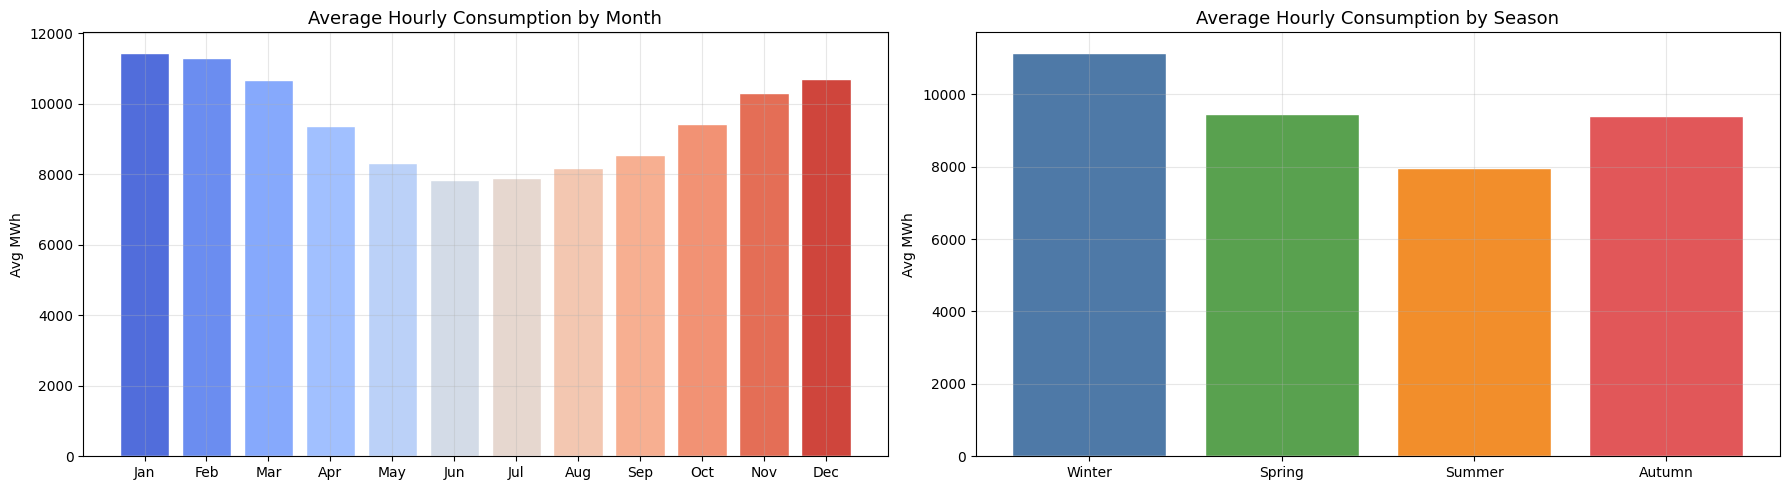

In [9]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

month_avg = df.groupby('month')['consumption_mwh'].mean()
axes[0].bar(month_names, month_avg.values, color=sns.color_palette('coolwarm', 12), edgecolor='white')
axes[0].set_title('Average Hourly Consumption by Month', fontsize=13)
axes[0].set_ylabel('Avg MWh')

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_avg = df.groupby('season')['consumption_mwh'].mean().reindex(season_order)
axes[1].bar(season_avg.index, season_avg.values,
            color=['#4e79a7','#59a14f','#f28e2b','#e15759'], edgecolor='white')
axes[1].set_title('Average Hourly Consumption by Season', fontsize=13)
axes[1].set_ylabel('Avg MWh')

plt.tight_layout()
plt.savefig('../outputs/figures/04_monthly_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Year-over-Year Trend

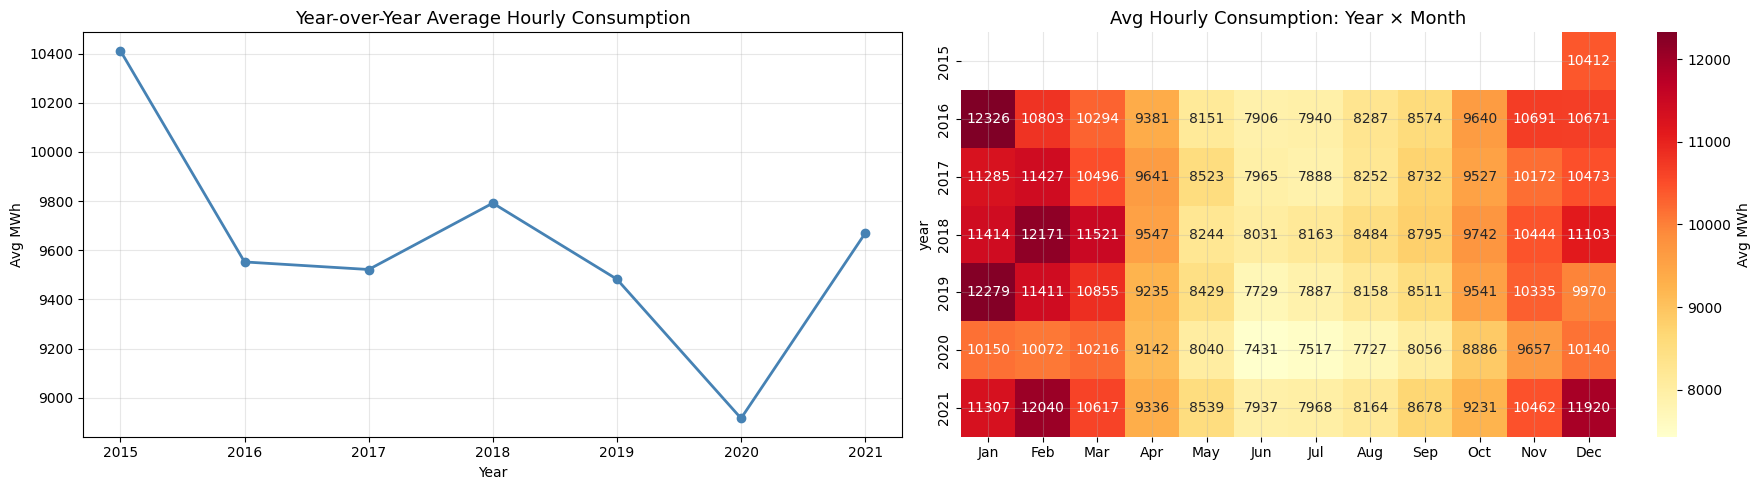

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Annual mean
yearly_avg = df.groupby('year')['consumption_mwh'].mean()
axes[0].plot(yearly_avg.index, yearly_avg.values, marker='o', lw=2, color='steelblue')
axes[0].set_title('Year-over-Year Average Hourly Consumption', fontsize=13)
axes[0].set_ylabel('Avg MWh')
axes[0].set_xlabel('Year')

# Monthly average per year (heatmap)
pivot_ym = df.groupby(['year', 'month'])['consumption_mwh'].mean().unstack()
pivot_ym.columns = month_names
sns.heatmap(pivot_ym, ax=axes[1], cmap='YlOrRd', fmt='.0f', annot=True,
            cbar_kws={'label': 'Avg MWh'})
axes[1].set_title('Avg Hourly Consumption: Year × Month', fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/figures/05_yoy_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Outlier Detection

IQR outliers (3×IQR): 0 (0.00%)
Z-score outliers (|z|>3.5): 3 (0.01%)
IQR bounds: [1482, 17442]


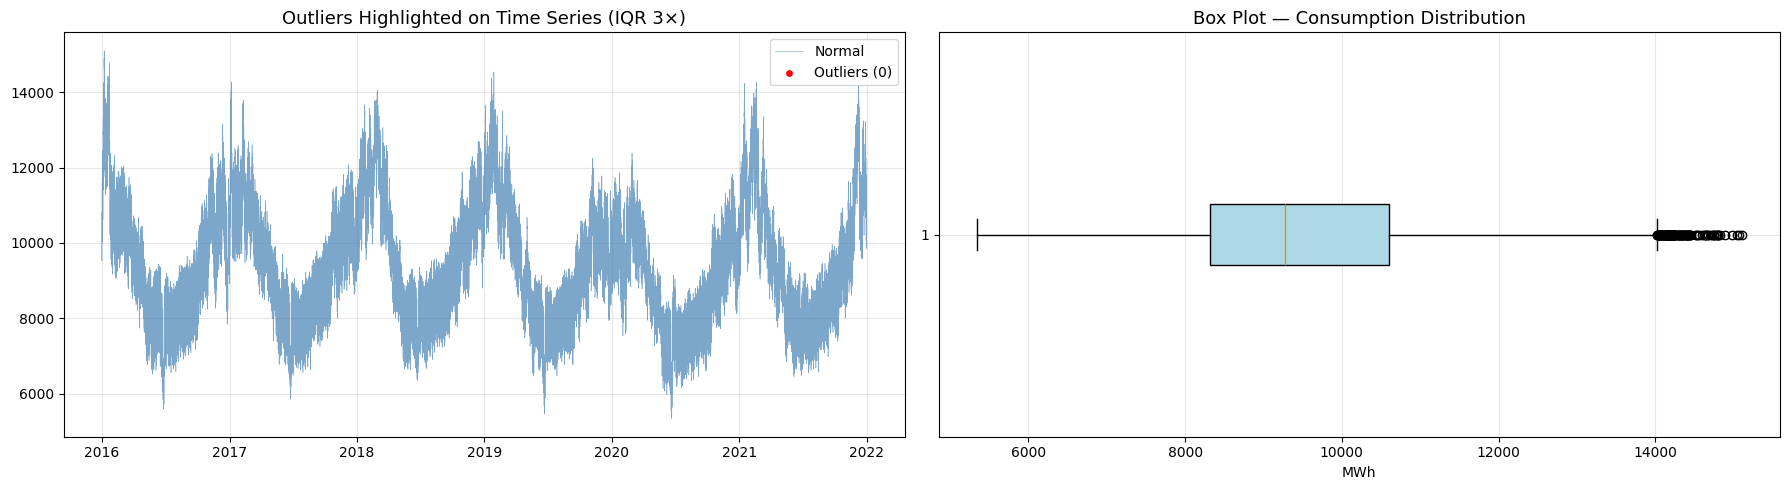

In [11]:
# IQR method
Q1 = df['consumption_mwh'].quantile(0.25)
Q3 = df['consumption_mwh'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
outliers_iqr = df[(df['consumption_mwh'] < lower) | (df['consumption_mwh'] > upper)]

# Z-score method
z_scores = np.abs(stats.zscore(df['consumption_mwh']))
outliers_z = df[z_scores > 3.5]

print(f'IQR outliers (3×IQR): {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)')
print(f'Z-score outliers (|z|>3.5): {len(outliers_z)} ({len(outliers_z)/len(df)*100:.2f}%)')
print(f'IQR bounds: [{lower:.0f}, {upper:.0f}]')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(df.index, df['consumption_mwh'], lw=0.4, color='steelblue', alpha=0.7, label='Normal')
axes[0].scatter(outliers_iqr.index, outliers_iqr['consumption_mwh'],
                color='red', s=15, zorder=5, label=f'Outliers ({len(outliers_iqr)})')
axes[0].set_title('Outliers Highlighted on Time Series (IQR 3×)', fontsize=13)
axes[0].legend()

axes[1].boxplot(df['consumption_mwh'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Box Plot — Consumption Distribution', fontsize=13)
axes[1].set_xlabel('MWh')

plt.tight_layout()
plt.savefig('../outputs/figures/06_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Distribution Analysis

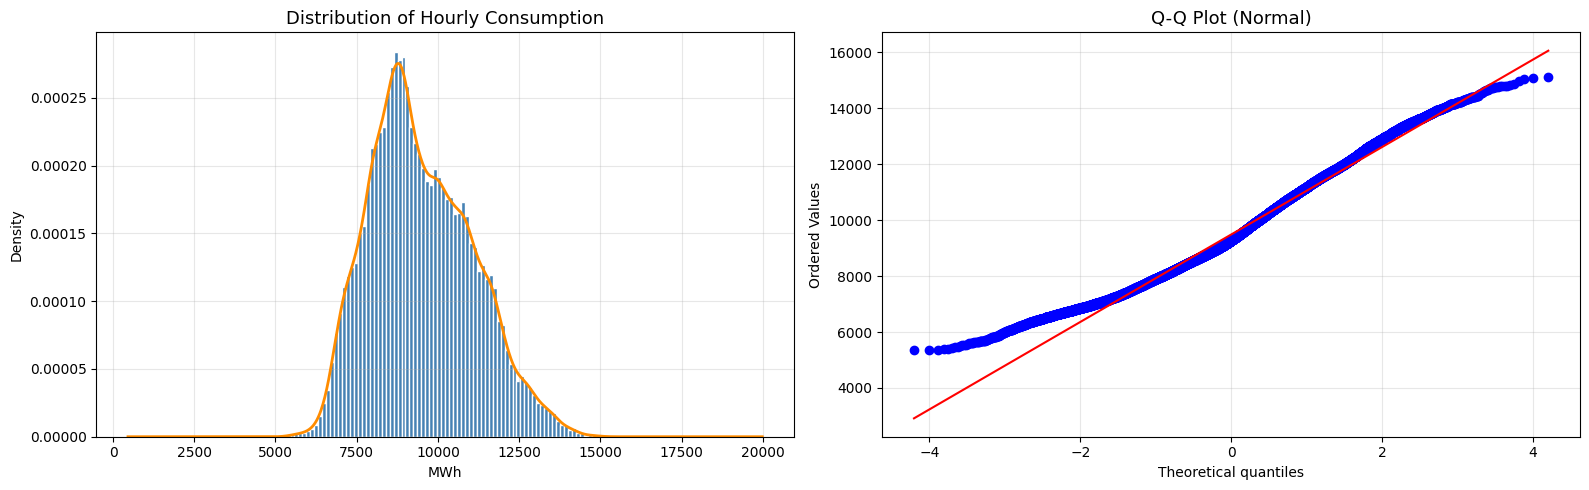

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['consumption_mwh'], bins=80, color='steelblue', edgecolor='white', density=True)
df['consumption_mwh'].plot(kind='density', ax=axes[0], color='darkorange', lw=2)
axes[0].set_title('Distribution of Hourly Consumption', fontsize=13)
axes[0].set_xlabel('MWh')
axes[0].set_ylabel('Density')

stats.probplot(df['consumption_mwh'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal)', fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/figures/07_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Seasonal Decomposition

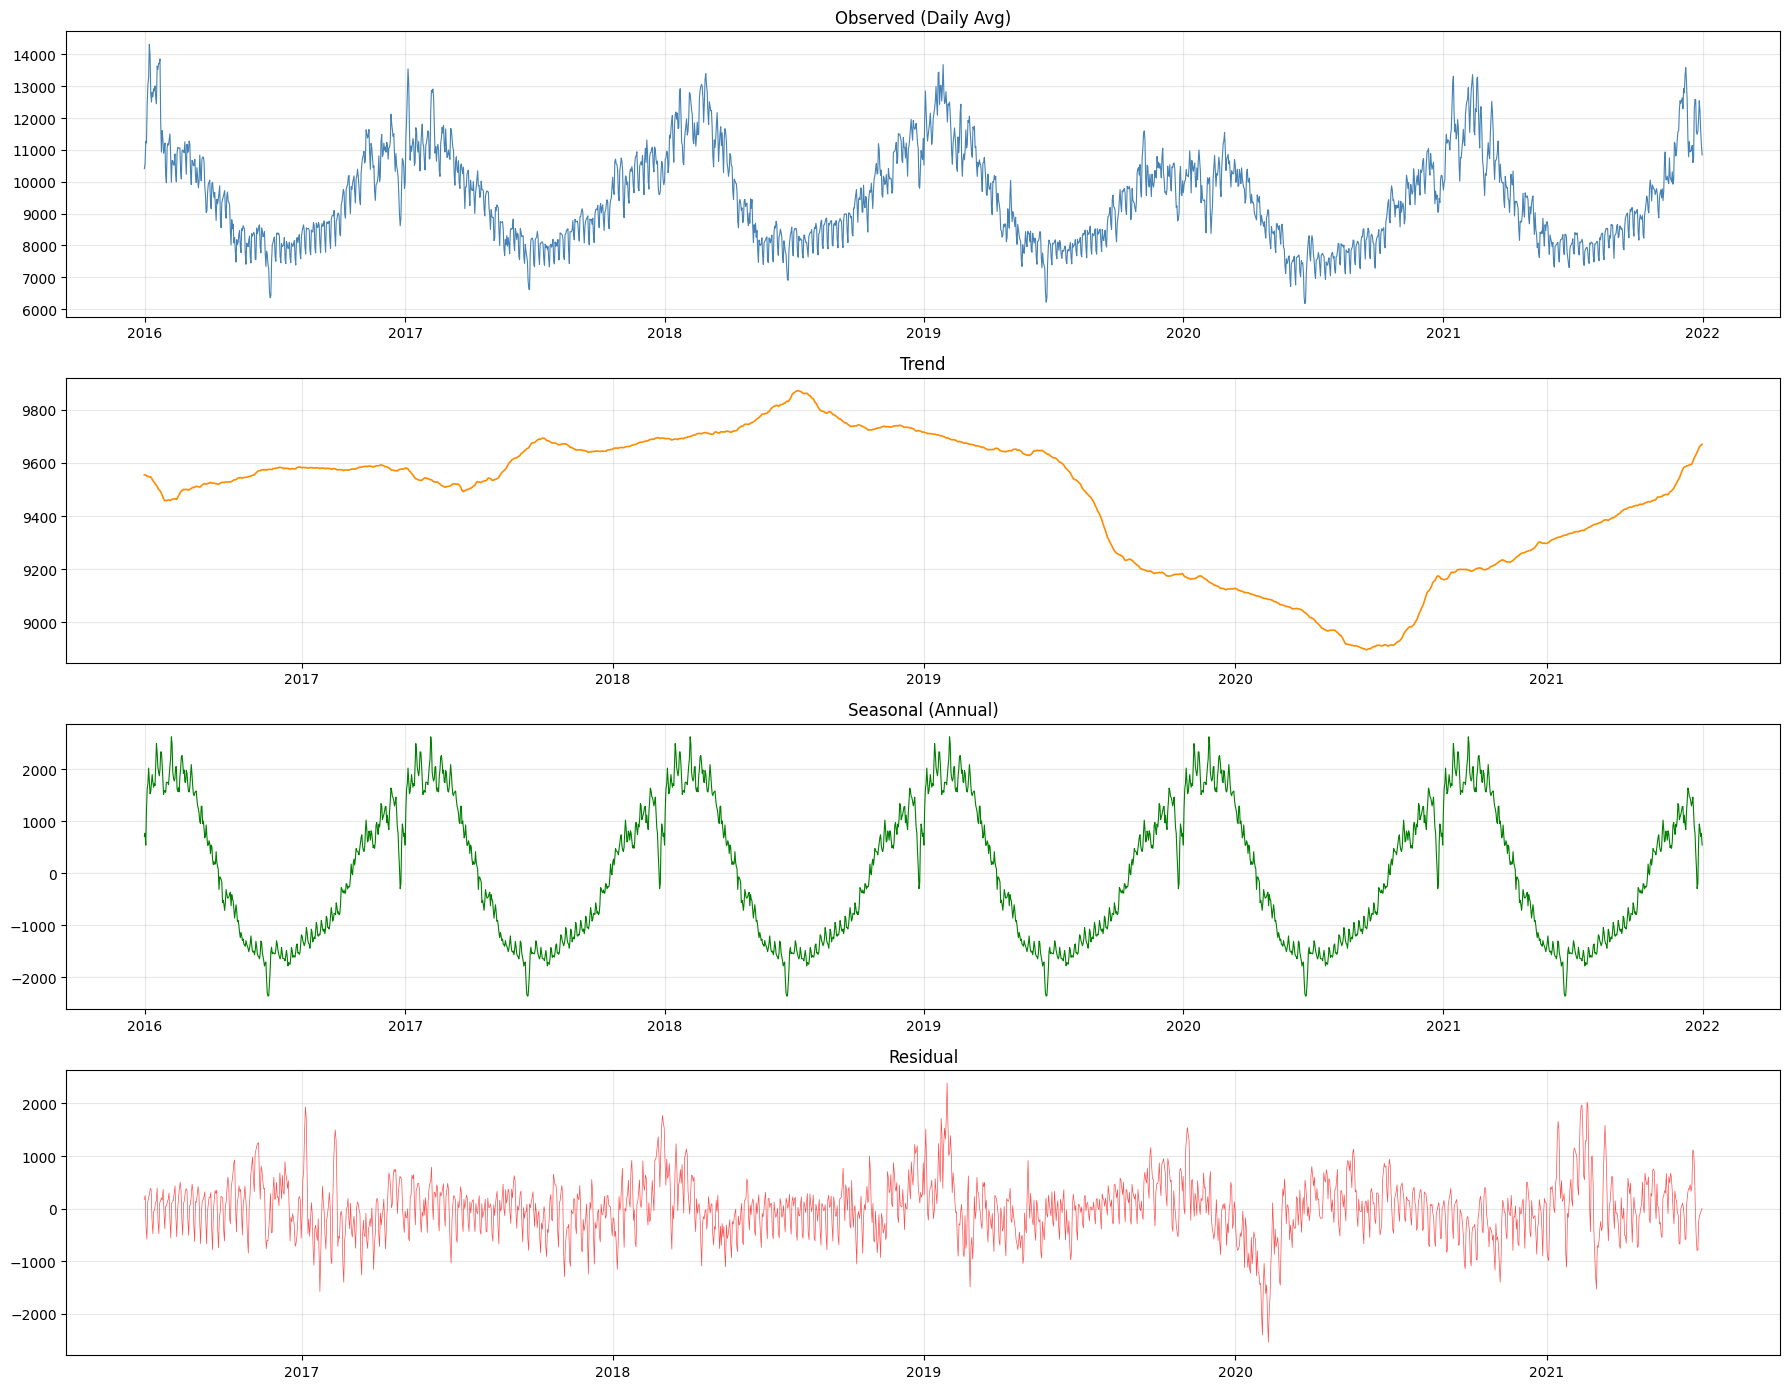

In [13]:
# Use daily resampled for decomposition (168 = weekly period)
daily_series = df['consumption_mwh'].resample('D').mean().dropna()

decomposition = seasonal_decompose(daily_series, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(18, 14))
axes[0].plot(daily_series, lw=0.8, color='steelblue')
axes[0].set_title('Observed (Daily Avg)', fontsize=12)
axes[1].plot(decomposition.trend, lw=1.2, color='darkorange')
axes[1].set_title('Trend', fontsize=12)
axes[2].plot(decomposition.seasonal, lw=0.8, color='green')
axes[2].set_title('Seasonal (Annual)', fontsize=12)
axes[3].plot(decomposition.resid, lw=0.5, color='red', alpha=0.7)
axes[3].set_title('Residual', fontsize=12)
for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/08_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Autocorrelation & Partial Autocorrelation

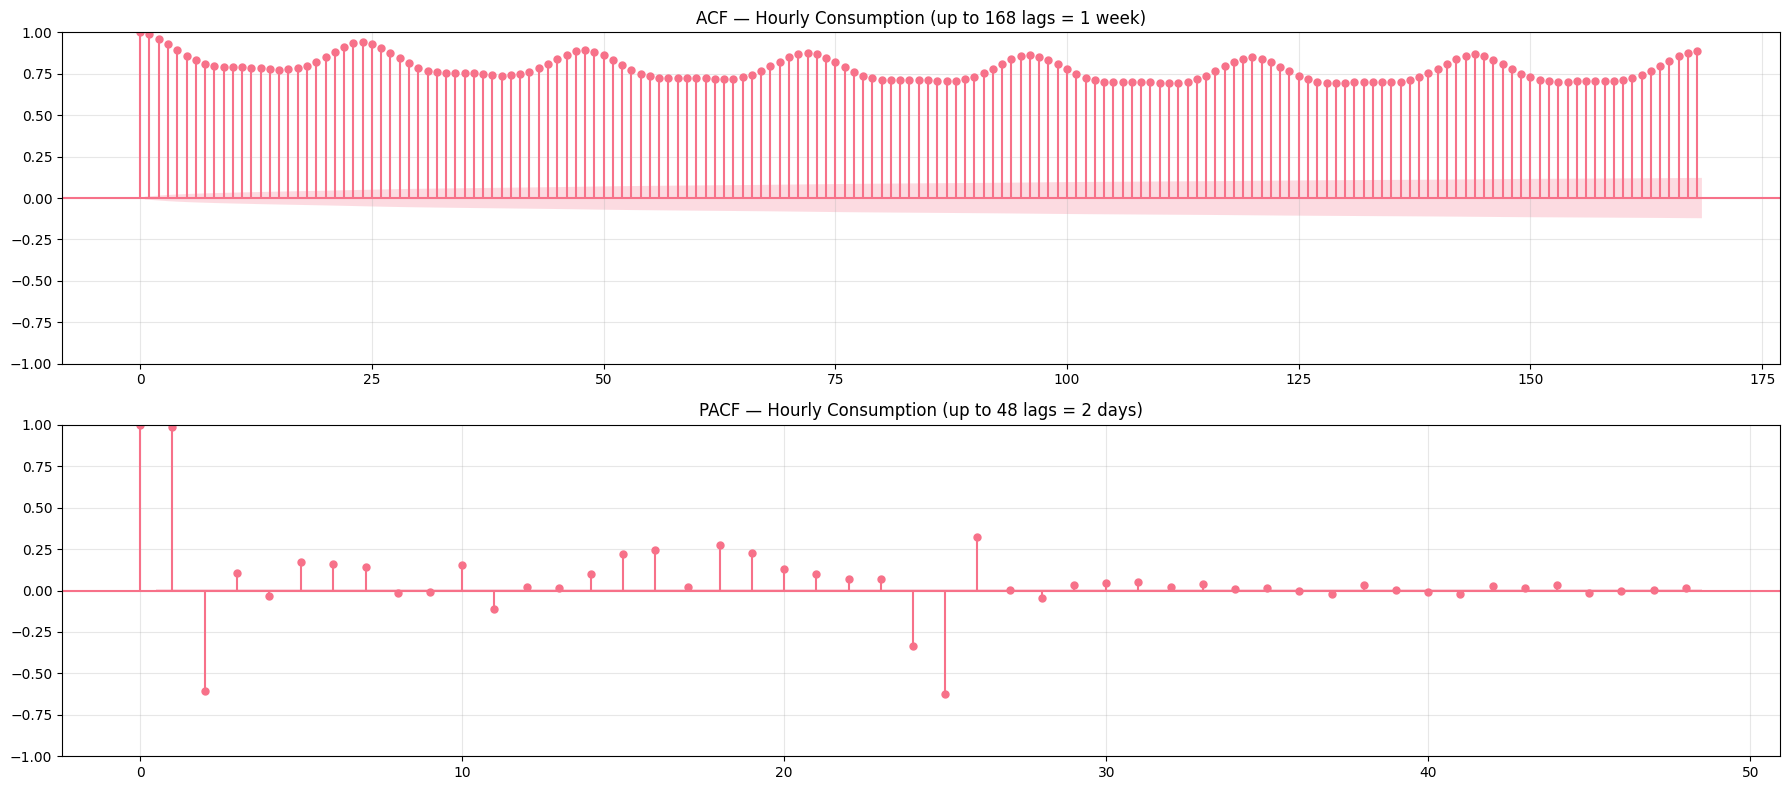

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))

plot_acf(df['consumption_mwh'].dropna(), lags=168, ax=axes[0],
         title='ACF — Hourly Consumption (up to 168 lags = 1 week)', alpha=0.05)
plot_pacf(df['consumption_mwh'].dropna(), lags=48, ax=axes[1],
          title='PACF — Hourly Consumption (up to 48 lags = 2 days)', alpha=0.05)

plt.tight_layout()
plt.savefig('../outputs/figures/09_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Rolling Statistics (Trend Check)

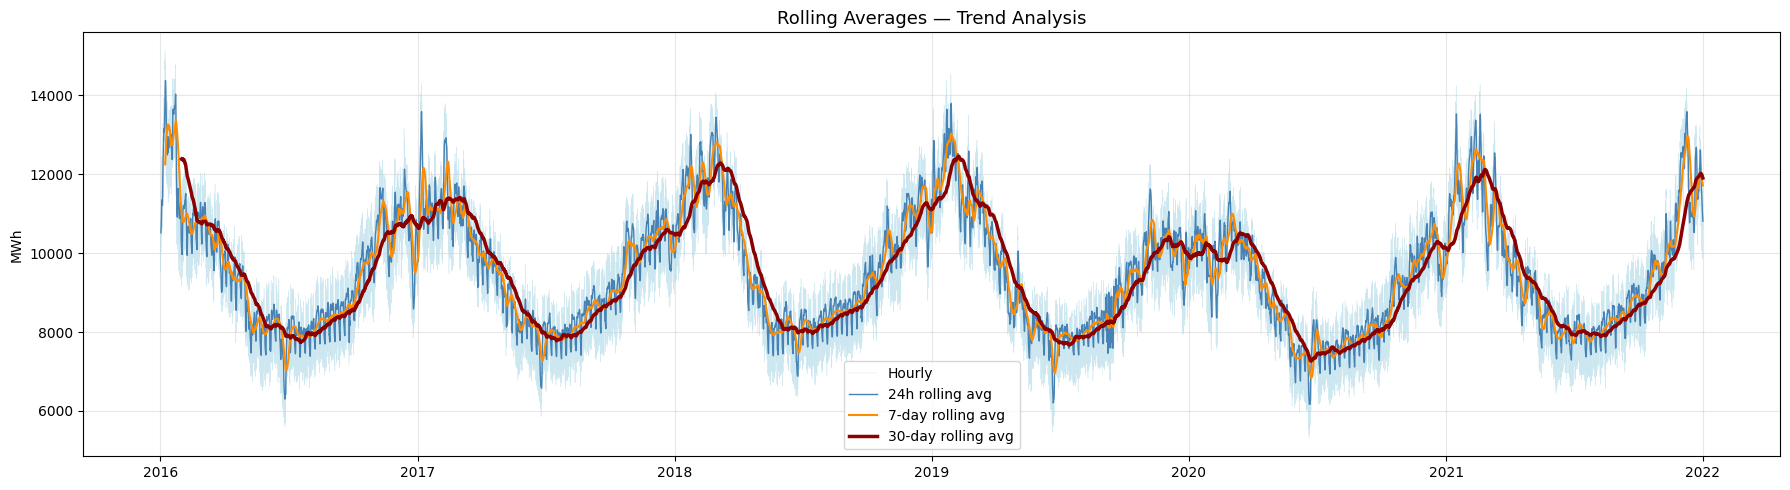

In [15]:
roll_24  = df['consumption_mwh'].rolling(24).mean()    # 24h
roll_168 = df['consumption_mwh'].rolling(168).mean()   # 1 week
roll_720 = df['consumption_mwh'].rolling(720).mean()   # 30 days

plt.figure(figsize=(18, 5))
plt.plot(df.index, df['consumption_mwh'], lw=0.3, color='lightblue', alpha=0.6, label='Hourly')
plt.plot(roll_24.index, roll_24, lw=1, color='steelblue', label='24h rolling avg')
plt.plot(roll_168.index, roll_168, lw=1.5, color='darkorange', label='7-day rolling avg')
plt.plot(roll_720.index, roll_720, lw=2.5, color='darkred', label='30-day rolling avg')
plt.title('Rolling Averages — Trend Analysis', fontsize=13)
plt.ylabel('MWh')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/10_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Sample Week Deep-Dive

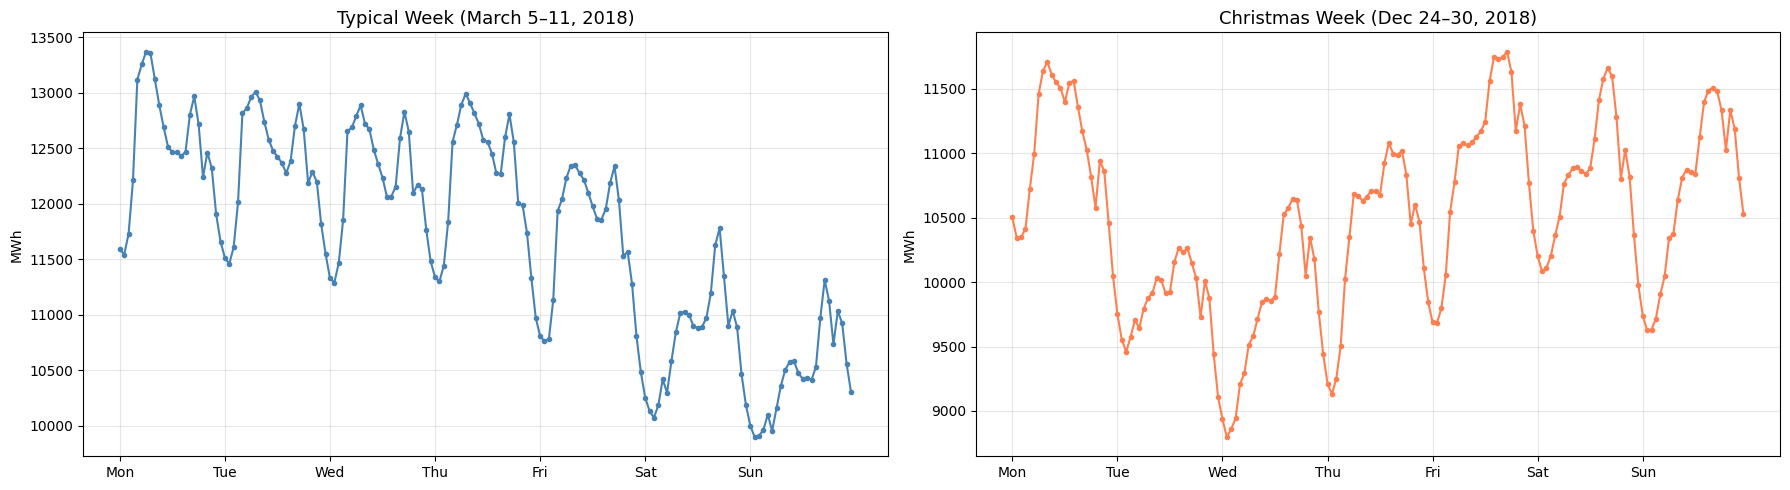

In [16]:
# Pick a typical week and a holiday week for comparison
typical_week  = df['2018-03-05':'2018-03-11']['consumption_mwh']
holiday_week  = df['2018-12-24':'2018-12-30']['consumption_mwh']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(typical_week.values, marker='o', ms=3, lw=1.5, color='steelblue')
axes[0].set_xticks(range(0, len(typical_week), 24))
axes[0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0].set_title('Typical Week (March 5–11, 2018)', fontsize=13)
axes[0].set_ylabel('MWh')

axes[1].plot(holiday_week.values, marker='o', ms=3, lw=1.5, color='coral')
axes[1].set_xticks(range(0, len(holiday_week), 24))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_title('Christmas Week (Dec 24–30, 2018)', fontsize=13)
axes[1].set_ylabel('MWh')

plt.tight_layout()
plt.savefig('../outputs/figures/11_sample_weeks.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Correlation with Lag Features

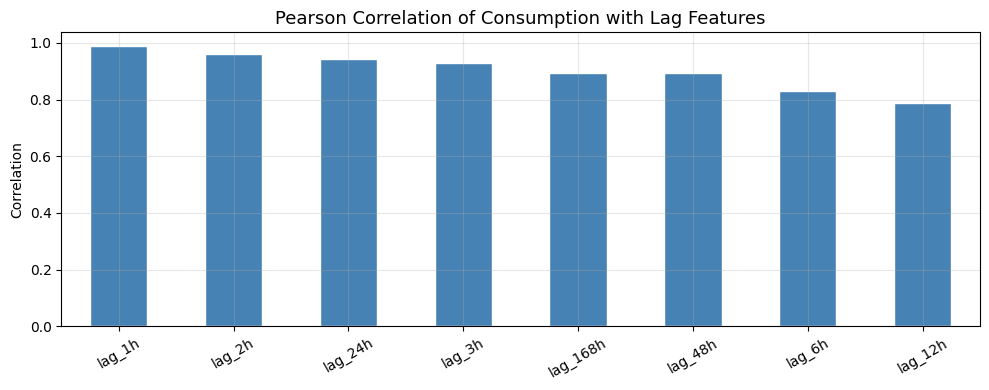

lag_1h      0.987969
lag_2h      0.961582
lag_24h     0.942411
lag_3h      0.928635
lag_168h    0.895387
lag_48h     0.894589
lag_6h      0.830796
lag_12h     0.786705
Name: t, dtype: float64


In [17]:
lag_df = pd.DataFrame({'t': df['consumption_mwh']})
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    lag_df[f'lag_{lag}h'] = df['consumption_mwh'].shift(lag)

corr = lag_df.corr()['t'].drop('t').sort_values(ascending=False)

plt.figure(figsize=(10, 4))
corr.plot(kind='bar', color=['steelblue' if v >= 0 else 'coral' for v in corr.values], edgecolor='white')
plt.title('Pearson Correlation of Consumption with Lag Features', fontsize=13)
plt.ylabel('Correlation')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/figures/12_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr)

## 17. EDA Summary & Key Findings

| Finding | Detail |
|---|---|
| **Dataset** | ~52,966 hourly records, 2016–2021 |
| **Daily pattern** | Two peaks: morning ramp-up (~8–10h) and evening peak (~17–20h) |
| **Weekly pattern** | Weekends ~10–15% lower than weekdays |
| **Annual seasonality** | Winter months highest; Spring/Autumn lowest |
| **Lag correlation** | lag_24h and lag_168h highly correlated → strong features |
| **Trend** | Relatively stable with a mild downward/flat trend |
| **Anomalies** | Holiday periods show clear dips; a few extreme outliers exist |

### Recommended Next Steps
1. Handle missing timestamps via interpolation  
2. Cap/flag outliers using IQR 3× rule  
3. Engineer lag features: t-1h, t-24h, t-168h  
4. Add rolling stats: 24h/168h mean and std  
5. Add `is_holiday` flag (national holidays)  
6. Model recommendation: **XGBoost** (fast, strong baseline) + **LSTM** (captures temporal patterns)

## 18. Save Cleaned Dataset

In [18]:
# Reindex to fill missing timestamps, then interpolate
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
df_clean = df[['consumption_mwh']].reindex(full_idx)
df_clean.index.name = 'timestamp'

# Linear interpolation for gaps
df_clean['consumption_mwh'] = df_clean['consumption_mwh'].interpolate(method='time')

# Cap outliers (optional — uncomment to apply)
# df_clean['consumption_mwh'] = df_clean['consumption_mwh'].clip(lower=lower, upper=upper)

df_clean.to_csv('../data/energy_clean.csv')
print(f'Saved cleaned dataset: {df_clean.shape}')
df_clean.tail()

Saved cleaned dataset: (52608, 1)

,consumption_mwh
timestamp,
2021-12-31 16:00:00,11447.0
2021-12-31 17:00:00,11237.0
2021-12-31 18:00:00,10914.0
2021-12-31 19:00:00,10599.0
2021-12-31 20:00:00,10812.0
